# Sentiment Analysis Based on Spotify App Reviews

Dataset: https://www.kaggle.com/datasets/mfaaris/spotify-app-reviews-2022

The dataset contains a collection of Spotify app reviews along with their ratings.

Goal: Build a model that, based on the content of reviews, can correctly classify them into one of three sentiment classes: positive, neutral, or negative.

In [1]:
# Tested on Python 3.14.3

# Libraries used in the project
import plot_confusion_matrix
import pandas as pd
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer
import re
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from textblob import TextBlob
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split, ShuffleSplit, GridSearchCV

## Loading the Data

In [2]:
# Load dataset
spotify = pd.read_csv("reviews.csv", sep = ",")

In [3]:
# Preview data
spotify.head(10)

,Time_submitted,Review,Rating,Total_thumbsup,Reply
0,2022-07-09 15:00:00,"Great music service, the audio is high quality...",5,2,NaN
1,2022-07-09 14:21:22,Please ignore previous negative rating. This a...,5,1,NaN
2,2022-07-09 13:27:32,"This pop-up ""Get the best Spotify experience o...",4,0,NaN
3,2022-07-09 13:26:45,Really buggy and terrible to use as of recently,1,1,NaN
4,2022-07-09 13:20:49,Dear Spotify why do I get songs that I didn't ...,1,1,NaN
5,2022-07-09 13:20:20,The player controls sometimes disappear for no...,3,7,NaN
6,2022-07-09 13:19:21,I love the selection and the lyrics are provid...,5,0,NaN
7,2022-07-09 13:17:22,Still extremely slow when changing storage to ...,3,16,NaN
8,2022-07-09 13:16:49,It's a great app and the best mp3 music app I ...,5,0,NaN
9,2022-07-09 13:11:32,"I'm deleting this app, for the following reaso...",1,318,NaN


In [4]:
# Remove columns not needed for the analysis: Time_submitted, Total_thumbsup, Reply
columns_to_delete = ['Time_submitted', 'Total_thumbsup', 'Reply']
spotify = spotify.drop(columns = columns_to_delete)

## Initial Exploration
- distribution of review ratings
- distribution of character count in reviews
- distribution of word count in reviews
- check for empty reviews
- distribution of the most frequent words in the corpus

### Distribution of Review Ratings

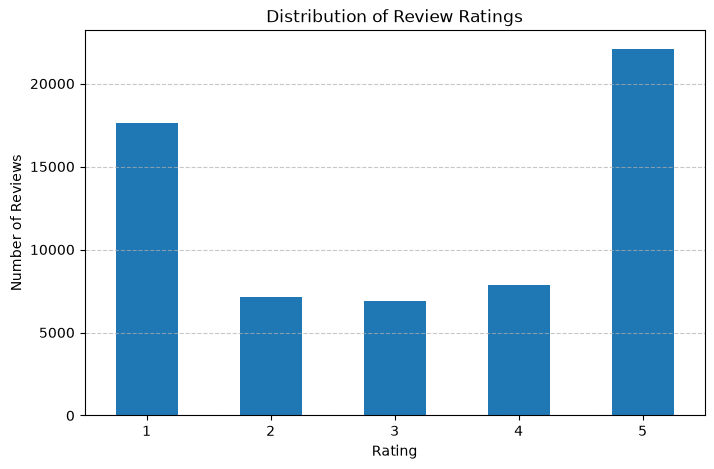

In [5]:
plt.figure(figsize=(8, 5))
spotify['Rating'].value_counts(sort=False).sort_index().plot(kind='bar')
plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Rating 1 (lowest) and 5 (highest) are given most frequently, while ratings 2, 3, and 4 are less common.

### Distribution of Character Count in Reviews

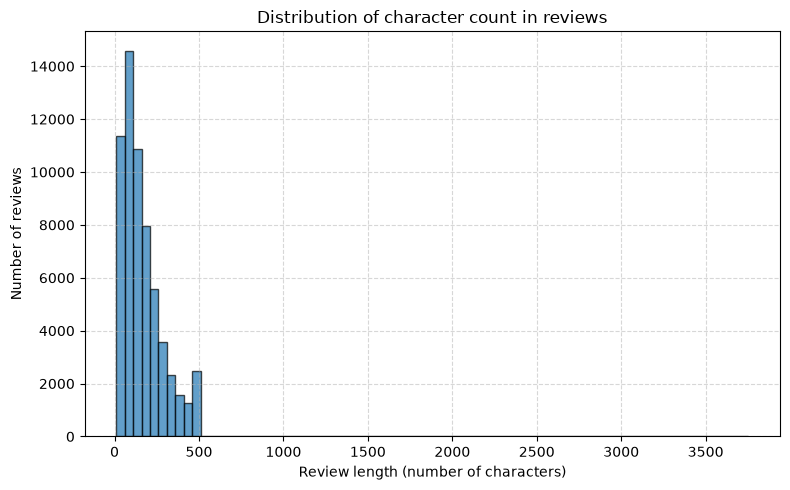

Each histogram bar represents approximately 50 characters.


In [6]:
# Create a histogram
plt.figure(figsize=(8, 5))
number_of_characters = spotify['Review'].str.len()
counts, bins, _ = plt.hist(
    number_of_characters,
    bins=75,
    edgecolor='black',
    alpha=0.7
)
plt.xlabel('Review length (number of characters)')
plt.ylabel('Number of reviews')
plt.title('Distribution of character count in reviews')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

bin_width_characters = bins[1] - bins[0]
print(f"Each histogram bar represents approximately {bin_width_characters:.0f} characters.")

In [7]:
# Basic statistics on numeber of characters
print(f"""
No. of reviews: {number_of_characters.count()}
Avg. characters per review: {number_of_characters.mean():.2f}
Min. characters in a review: {number_of_characters.min()}
Max. characters in a review: {number_of_characters.max()}
50th percentile: {number_of_characters.quantile(0.5):.0f} characters
75th percentile: {number_of_characters.quantile(0.75):.0f} characters
90th percentile: {number_of_characters.quantile(0.9):.0f} characters
    """)


No. of reviews: 61594
Avg. characters per review: 163.32
Min. characters in a review: 10
Max. characters in a review: 3753
50th percentile: 130 characters
75th percentile: 221 characters
90th percentile: 339 characters
    


Most reviews are short, with three-quarters containing fewer than 200 characters. The distribution shows a long right tail, indicating that lengthy reviews are relatively uncommon.

### Distribution of Word Count in Reviews

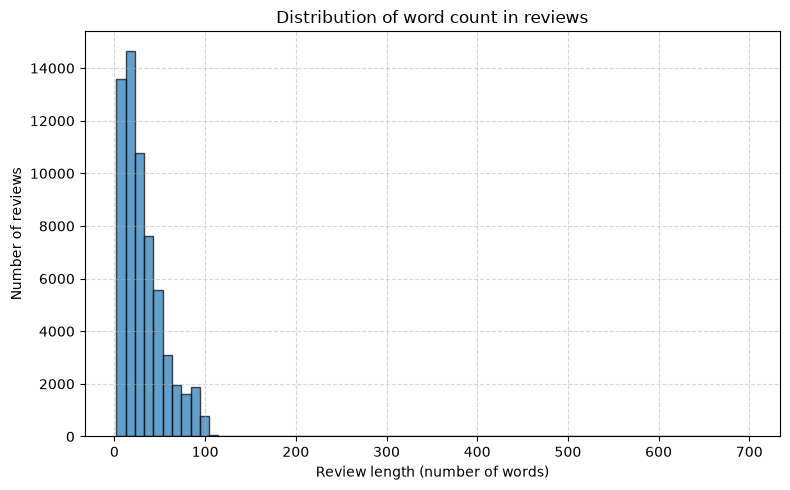

Each histogram bar represents approximately 10 words.


In [8]:
# Create a histogram
plt.figure(figsize=(8, 5))
number_of_words = spotify['Review'].str.split().map(lambda x: len(x))
counts, bins, _ = plt.hist(
    number_of_words,
    bins=68,
    edgecolor='black',
    alpha=0.7
)
plt.xlabel('Review length (number of words)')
plt.ylabel('Number of reviews')
plt.title('Distribution of word count in reviews')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

bin_width_words = bins[1] - bins[0]
print(f"Each histogram bar represents approximately {bin_width_words:.0f} words.")

In [9]:
# Basic statistics on number of words
print(f"""
No. of reviews: {number_of_words.count()}
Avg. words per review: {number_of_words.mean():.2f}
Min. words in a review: {number_of_words.min()}
Max. words in a review: {number_of_words.max()}
50th percentile: {number_of_words.quantile(0.5):.0f} words
75th percentile: {number_of_words.quantile(0.75):.0f} words
90th percentile: {number_of_words.quantile(0.9):.0f} words
    """)


No. of reviews: 61594
Avg. words per review: 30.89
Min. words in a review: 2
Max. words in a review: 699
50th percentile: 25 words
75th percentile: 42 words
90th percentile: 64 words
    


Most reviews are short, with three-quarters containing fewer than 40 words.

### Checking for Empty Reviews

In [10]:
# Identify empty reviews
empty_reviews = spotify['Review'].str.strip().str.len() == 0

# Filter empty reviews
empty_reviews_df = spotify[empty_reviews]
print("Number of empty reviews:", empty_reviews_df.shape[0])
empty_reviews_df.head(10)

Number of empty reviews: 0


,Review,Rating


The dataset doesn't contain any empty reviews.

#### Distribution of Most Frequent Words in the Corpus

In [11]:
# Build a corpus from raw data: a list of all words across all reviews
corpus = []
for x in spotify["Review"].str.split():
    corpus.extend(x)

In [12]:
# Extract the most frequent words and their frequencies
counter = Counter(corpus)
most = counter.most_common()

In [13]:
# Create a list of the 40 most frequent words in the corpus
first_n = 40
x, y = [], []
for word,count in most[:first_n]:
    x.append(word)
    y.append(count)

40 most frequent words in the corpus


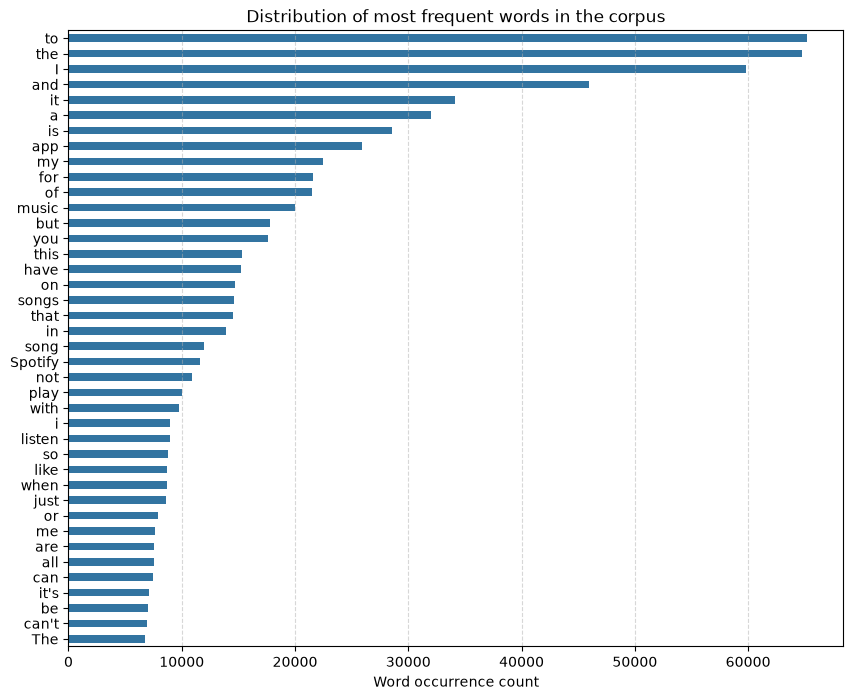

In [14]:
# Create a plot of the most frequent words in the corpus
plt.figure(figsize=(10, 8))
sns.barplot(x=y,y=x, width=0.5)
plt.xlabel('Word occurrence count')
plt.title('Distribution of most frequent words in the corpus')
plt.grid(axis='x', linestyle='--', alpha=0.5)
print(f"{first_n} most frequent words in the corpus")
plt.show()

Most of these are stopwords — common words that carry little or no semantic meaning, as well as domain-specific words that occur frequently across all sentiment classes. Such words are typically removed before further analysis.

## Text Preprocessing for the Review Column
- data cleaning
- word tokenisation
- stemming and lemmatisation
- defining and removing stopwords

### Data Cleaning

In [15]:
# Define a text cleaning function
def preprocessor(text):
    text = re.sub('<[^>]*>', '', text)
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)
    text = re.sub(r"[^\w\s\']", ' ', text.lower()) +\
        ' '.join(emoticons).replace('-', '')
    return text

The preprocessing function removes HTML tags, converts text to lowercase, extracts and preserves emoticons, and removes punctuation and special characters while retaining apostrophes within words.

Apostrophes were intentionally retained because they play an important role in sentiment analysis, particularly in identifying negations (e.g., don’t, can’t), which are likely to be critical for classifying negative sentiment. Similarly, emoticons were preserved as they may provide additional information about the sentiment expressed in a review.

In [16]:
# Check the text after cleaning
example = spotify.loc[4, 'Review'][0:165]
print(f"""
Original text: \n{example}
      
After cleaning: \n{preprocessor(example)}
""")


Original text: 
Dear Spotify why do I get songs that I didn't put on my playlist??? And why do we have shuffle play?

After cleaning: 
dear spotify why do i get songs that i didn't put on my playlist    and why do we have shuffle play 



In [17]:
# Save the cleaned review text to a separate column
spotify["review_cleaned"] = spotify['Review'].apply(preprocessor)
spotify.head(5)

,Review,Rating,review_cleaned
0,"Great music service, the audio is high quality...",5,great music service the audio is high quality...
1,Please ignore previous negative rating. This a...,5,please ignore previous negative rating this a...
2,"This pop-up ""Get the best Spotify experience o...",4,this pop up get the best spotify experience o...
3,Really buggy and terrible to use as of recently,1,really buggy and terrible to use as of recently
4,Dear Spotify why do I get songs that I didn't ...,1,dear spotify why do i get songs that i didn't ...


### Word Tokenisation

In [18]:
# Test the NLTK word_tokenize tokenizer on cleaned data
example = spotify["review_cleaned"][4]
print(f"""
Before tokenisation:
{example}

After word tokenisation:
{word_tokenize(example)}    
      """)


Before tokenisation:
dear spotify why do i get songs that i didn't put on my playlist    and why do we have shuffle play 

After word tokenisation:
['dear', 'spotify', 'why', 'do', 'i', 'get', 'songs', 'that', 'i', 'did', "n't", 'put', 'on', 'my', 'playlist', 'and', 'why', 'do', 'we', 'have', 'shuffle', 'play']    
      


The default NLTK tokenizer separates contractions such as didn’t into two tokens (did and n’t). Because contractions may carry important sentiment information, particularly through negation, I will implement a custom tokenizer that preserves them as single tokens.

In [19]:
# Define a custom tokenizer that preserves contractions
def contraction_tokenizer(text):
    return re.findall(r"\b\w+(?:'\w+)?\b", text)

# Test the custom tokenizer on cleaned data
example = spotify["review_cleaned"][4]
print(f"""
Before tokenisation:
{example}

After custom tokenisation:
{contraction_tokenizer(example)}    
    """)


Before tokenisation:
dear spotify why do i get songs that i didn't put on my playlist    and why do we have shuffle play 

After custom tokenisation:
['dear', 'spotify', 'why', 'do', 'i', 'get', 'songs', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'why', 'do', 'we', 'have', 'shuffle', 'play']    
    


In [20]:
# Tokenize all cleaned reviews using the custom tokenizer
tqdm.pandas()
spotify["review_tokens"] = spotify['review_cleaned'].progress_apply(contraction_tokenizer)

spotify.head(5)

100%|██████████| 61594/61594 [00:00<00:00, 234374.06it/s]


,Review,Rating,review_cleaned,review_tokens
0,"Great music service, the audio is high quality...",5,great music service the audio is high quality...,"[great, music, service, the, audio, is, high, ..."
1,Please ignore previous negative rating. This a...,5,please ignore previous negative rating this a...,"[please, ignore, previous, negative, rating, t..."
2,"This pop-up ""Get the best Spotify experience o...",4,this pop up get the best spotify experience o...,"[this, pop, up, get, the, best, spotify, exper..."
3,Really buggy and terrible to use as of recently,1,really buggy and terrible to use as of recently,"[really, buggy, and, terrible, to, use, as, of..."
4,Dear Spotify why do I get songs that I didn't ...,1,dear spotify why do i get songs that i didn't ...,"[dear, spotify, why, do, i, get, songs, that, ..."


### Stemming and Lemmatisation

In [21]:
# Test the PorterStemmer from NLTK
porter = PorterStemmer()

def stem_porter(tokens):
    return [porter.stem(token) for token in tokens]

example = spotify["review_tokens"][4]
print(f"""
Before stemming:
{example}

After stemming:
{stem_porter(example)}    
    """)


Before stemming:
['dear', 'spotify', 'why', 'do', 'i', 'get', 'songs', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'why', 'do', 'we', 'have', 'shuffle', 'play']

After stemming:
['dear', 'spotifi', 'whi', 'do', 'i', 'get', 'song', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'whi', 'do', 'we', 'have', 'shuffl', 'play']    
    


The Porter Stemmer’s results aren’t entirely satisfactory. In particular, words ending in -y are often modified by replacing the final y with i (e.g., spotify → spotifi). I’ll therefore also test NLTK’s Snowball Stemmer to see whether it produces more meaningful stems.

In [22]:
# Test the SnowballStemmer from NLTK
snowball = SnowballStemmer("english")

def stem_snowball(tokens):
    return [snowball.stem(token) for token in tokens]

example = spotify["review_tokens"][4]
print(f"""
Before stemming:
{example}

After stemming:
{stem_snowball(example)}    
    """)


Before stemming:
['dear', 'spotify', 'why', 'do', 'i', 'get', 'songs', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'why', 'do', 'we', 'have', 'shuffle', 'play']

After stemming:
['dear', 'spotifi', 'whi', 'do', 'i', 'get', 'song', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'whi', 'do', 'we', 'have', 'shuffl', 'play']    
    


The results are identical, and the issue still persists. I’ll therefore move on to lemmatization and test NLTK’s WordNetLemmatizer as an alternative to stemming.

In [23]:
# Test the WordNetLemmatizer from NLTK
WordNetLem = WordNetLemmatizer()

def lem_WordNet(tokens):
    return [WordNetLem.lemmatize(token) for token in tokens]

example = spotify["review_tokens"][4]
print(f"""
Before stemming:
{example}

After stemming:
{lem_WordNet(example)}    
    """)


Before stemming:
['dear', 'spotify', 'why', 'do', 'i', 'get', 'songs', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'why', 'do', 'we', 'have', 'shuffle', 'play']

After stemming:
['dear', 'spotify', 'why', 'do', 'i', 'get', 'song', 'that', 'i', "didn't", 'put', 'on', 'my', 'playlist', 'and', 'why', 'do', 'we', 'have', 'shuffle', 'play']    
    


Unlike stemming, lemmatization with NLTK’s WordNetLemmatizer produced the expected results, generating valid word forms instead of truncated stems.

In [24]:
# Lemmatize tokens in each review
spotify["review_lemmas"] = spotify["review_tokens"].progress_apply(lem_WordNet)
spotify.head(5)

100%|██████████| 61594/61594 [00:02<00:00, 30499.72it/s]


,Review,Rating,review_cleaned,review_tokens,review_lemmas
0,"Great music service, the audio is high quality...",5,great music service the audio is high quality...,"[great, music, service, the, audio, is, high, ...","[great, music, service, the, audio, is, high, ..."
1,Please ignore previous negative rating. This a...,5,please ignore previous negative rating this a...,"[please, ignore, previous, negative, rating, t...","[please, ignore, previous, negative, rating, t..."
2,"This pop-up ""Get the best Spotify experience o...",4,this pop up get the best spotify experience o...,"[this, pop, up, get, the, best, spotify, exper...","[this, pop, up, get, the, best, spotify, exper..."
3,Really buggy and terrible to use as of recently,1,really buggy and terrible to use as of recently,"[really, buggy, and, terrible, to, use, as, of...","[really, buggy, and, terrible, to, use, a, of,..."
4,Dear Spotify why do I get songs that I didn't ...,1,dear spotify why do i get songs that i didn't ...,"[dear, spotify, why, do, i, get, songs, that, ...","[dear, spotify, why, do, i, get, song, that, i..."


### Defining and Removing Stopwords

40 most frequent words in the corpus


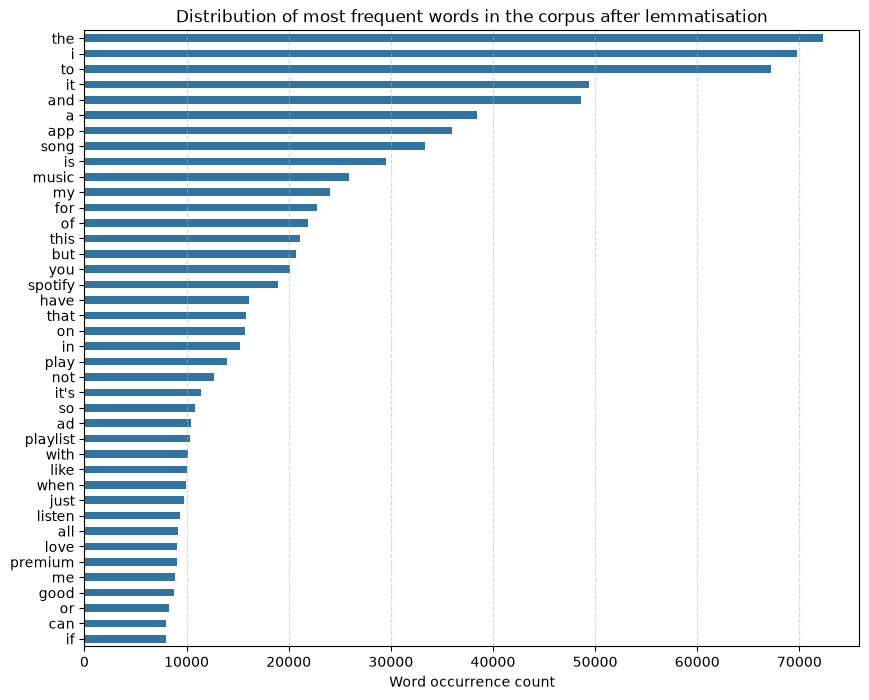

In [25]:
# Examine the corpus after lemmatization
corpus_lemmas = []
for tokens in spotify['review_lemmas']:
    if isinstance(tokens, list):
        corpus_lemmas.extend(tokens)

counts_lemmas = Counter(corpus_lemmas)
most_lemmas = counts_lemmas.most_common()

first_n = 40
x, y = [], []
for word,count in most_lemmas[:first_n]:
    x.append(word)
    y.append(count)

# Plot the most frequent words in the corpus after lemmatization
plt.figure(figsize=(10, 8))
sns.barplot(x=y,y=x, width=0.5)
plt.xlabel('Word occurrence count')
plt.title('Distribution of most frequent words in the corpus after lemmatisation')
plt.grid(axis='x', linestyle='--', alpha=0.5)
print(f"{first_n} most frequent words in the corpus")
plt.show()

As mentioned earlier, many of the most frequent terms are either stop words or domain-specific words that occur frequently across all sentiment classes and therefore provide little discriminative value. I’ll remove these terms from further analysis to reduce noise and focus on words that are more informative for sentiment classification.

In [26]:
# Download and preview the NLTK stopword list for English
english_stopwords = set(stopwords.words('english'))
print(f"Number of English stopwords: {len(english_stopwords)}")
print(f"NLTK stopwords are of type {type(english_stopwords)} \n")
print(sorted(english_stopwords))

Number of English stopwords: 198
NLTK stopwords are of type <class 'set'> 

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 

In [27]:
# Modify the stopword list by removing and adding selected terms
# This step is performed iteratively based on corpus analysis

# Remove selected stopwords (negations are preserved to retain negation context)
english_stopwords.difference_update(["don't", "didn't", "doesn't", "can't","couldn't", "isn't"])

# Add domain-specific terms and other low-value words that provide little information for sentiment classification
english_stopwords.update(['spotify', '12', 'wa', 'ha', "i'm", "i've", 'app', 'music', 'song', 'playlist', 'premium', 'ad', "play", "listen", "playing", "listening"])

print(sorted(english_stopwords))

['12', 'a', 'about', 'above', 'ad', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'app', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', 'd', 'did', 'didn', 'do', 'does', 'doesn', 'doing', 'don', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'ha', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'listen', 'listening', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'music', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 'play', 'playing', 'playlist', 'pre

In [28]:
spotify['review_free_stopwords'] = spotify['review_lemmas'].apply(
    lambda tokens: [word for word in tokens if word not in english_stopwords]
)
spotify.head(5)

,Review,Rating,review_cleaned,review_tokens,review_lemmas,review_free_stopwords
0,"Great music service, the audio is high quality...",5,great music service the audio is high quality...,"[great, music, service, the, audio, is, high, ...","[great, music, service, the, audio, is, high, ...","[great, service, audio, high, quality, easy, u..."
1,Please ignore previous negative rating. This a...,5,please ignore previous negative rating this a...,"[please, ignore, previous, negative, rating, t...","[please, ignore, previous, negative, rating, t...","[please, ignore, previous, negative, rating, s..."
2,"This pop-up ""Get the best Spotify experience o...",4,this pop up get the best spotify experience o...,"[this, pop, up, get, the, best, spotify, exper...","[this, pop, up, get, the, best, spotify, exper...","[pop, get, best, experience, android, annoying..."
3,Really buggy and terrible to use as of recently,1,really buggy and terrible to use as of recently,"[really, buggy, and, terrible, to, use, as, of...","[really, buggy, and, terrible, to, use, a, of,...","[really, buggy, terrible, use, recently]"
4,Dear Spotify why do I get songs that I didn't ...,1,dear spotify why do i get songs that i didn't ...,"[dear, spotify, why, do, i, get, songs, that, ...","[dear, spotify, why, do, i, get, song, that, i...","[dear, get, didn't, put, shuffle]"


40 most frequent words in the corpus


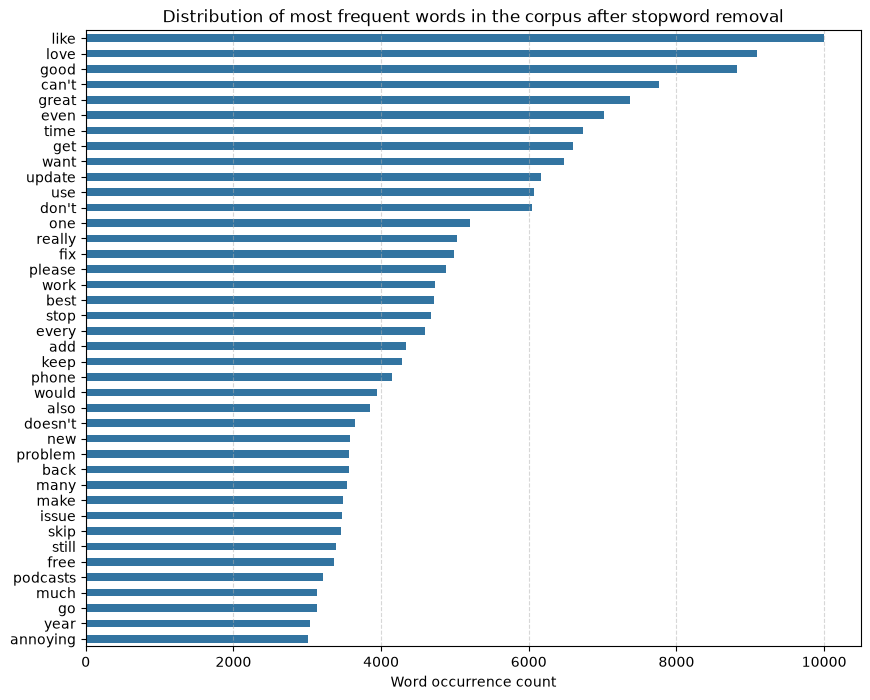

In [29]:
# Analyse the corpus after stopword removal
corpus_free_stopwords = []
for tokens in spotify['review_free_stopwords']:
    if isinstance(tokens, list):
        corpus_free_stopwords.extend(tokens)

counts_free_stopwords = Counter(corpus_free_stopwords)
most_free_stopwords = counts_free_stopwords.most_common()

first_n = 40
x, y= [], []
for word,count in most_free_stopwords[:first_n]:
    x.append(word)
    y.append(count)

# Plot the most frequent words after stopword removal
plt.figure(figsize=(10, 8))
sns.barplot(x=y,y=x, width=0.5)
plt.xlabel('Word occurrence count')
plt.title('Distribution of most frequent words in the corpus after stopword removal')
plt.grid(axis='x', linestyle='--', alpha=0.5)
print(f"{first_n} most frequent words in the corpus")
plt.show()

After removing stop words and low-information domain-specific terms, the most frequent words in the corpus are now more informative and should have a positive impact on sentiment modelling.

## Sentiment Modelling

To facilitate sentiment modelling, numerical ratings will be converted into three sentiment categories: positive (4–5), neutral (3), and negative (1–2). This reduces the complexity of the target variable while preserving the overall sentiment expressed by reviewers.

In [30]:
# Create sentiment classes from review ratings
# positive (4–5), neutral (3), and negative (1–2)
def assign_sentiment(rating):
    if rating in [5, 4]:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    elif rating in [1, 2]:
        return 'Negative'

spotify['sentiment'] = spotify['Rating'].apply(assign_sentiment)

spotify.head(5)

,Review,Rating,review_cleaned,review_tokens,review_lemmas,review_free_stopwords,sentiment
0,"Great music service, the audio is high quality...",5,great music service the audio is high quality...,"[great, music, service, the, audio, is, high, ...","[great, music, service, the, audio, is, high, ...","[great, service, audio, high, quality, easy, u...",Positive
1,Please ignore previous negative rating. This a...,5,please ignore previous negative rating this a...,"[please, ignore, previous, negative, rating, t...","[please, ignore, previous, negative, rating, t...","[please, ignore, previous, negative, rating, s...",Positive
2,"This pop-up ""Get the best Spotify experience o...",4,this pop up get the best spotify experience o...,"[this, pop, up, get, the, best, spotify, exper...","[this, pop, up, get, the, best, spotify, exper...","[pop, get, best, experience, android, annoying...",Positive
3,Really buggy and terrible to use as of recently,1,really buggy and terrible to use as of recently,"[really, buggy, and, terrible, to, use, as, of...","[really, buggy, and, terrible, to, use, a, of,...","[really, buggy, terrible, use, recently]",Negative
4,Dear Spotify why do I get songs that I didn't ...,1,dear spotify why do i get songs that i didn't ...,"[dear, spotify, why, do, i, get, songs, that, ...","[dear, spotify, why, do, i, get, song, that, i...","[dear, get, didn't, put, shuffle]",Negative


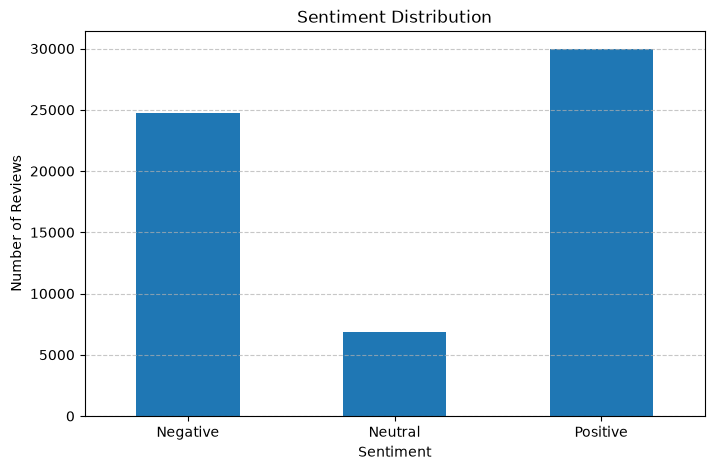

In [31]:
# Plot the distribution of sentiment classes
plt.figure(figsize=(8, 5))
spotify['sentiment'].value_counts(sort=False).sort_index().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The dataset contains mostly positive and negative reviews, while neutral reviews are much less common. Because there are fewer neutral reviews, they may be more difficult for the model to classify correctly.

In [32]:
# Define X (review text) and y (sentiment labels), then split the data into training and test sets
X = spotify["review_free_stopwords"].copy()
y = spotify["sentiment"].copy()

RANDOM_STATE = 33
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)

train_idx = X_train.index.tolist()
test_idx = X_test.index.tolist()

### Sentiment Analysis Using TextBlob

TextBlob will be applied to different versions of the review text to investigate whether preprocessing affects sentiment classification performance. As TextBlob relies on a predefined sentiment lexicon rather than being trained on the dataset, it represents a different approach to sentiment analysis than the machine learning models evaluated later in the analysis. The results will serve as a baseline for comparison with those models.

In [33]:
# Function that assigns sentiment labels based on TextBlob polarity scores:
# Positive (> 0), Neutral (= 0), Negative (< 0)
def textblob_sentiment(text):
    if isinstance(text, list):
        text = ' '.join(text)
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity == 0:
        return 'Neutral'
    elif polarity < 0:
        return 'Negative'

The TextBlob sentiment analyser computes a polarity score ranging from -1 to 1. Reviews with polarity > 0 are classified as positive, polarity = 0 as neutral, and polarity < 0 as negative.

In [34]:
# Checking labels in the test set
print(y_test.unique())

<StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str


In [35]:
# Generate sentiment predictions for the original test reviews
y_pred_test = list(map(lambda x: textblob_sentiment(x), tqdm(spotify.loc[test_idx]["Review"])))

# Evaluate TextBlob's sentiment classification performance
# Accuracy = (number of correct predictions) / (total number of predictions)
print(f"Accuracy on test set: {accuracy_score(y_test, y_pred_test)}")
print(classification_report(y_test, y_pred_test, target_names=['Negative','Neutral', 'Positive']))
print(confusion_matrix(y_test, y_pred_test))

100%|██████████| 18479/18479 [00:01<00:00, 11147.65it/s]


Accuracy on test set: 0.6138319173115429
              precision    recall  f1-score   support

    Negative       0.74      0.43      0.55      7342
     Neutral       0.13      0.12      0.12      2140
    Positive       0.65      0.88      0.75      8997

    accuracy                           0.61     18479
   macro avg       0.51      0.48      0.47     18479
weighted avg       0.63      0.61      0.60     18479

[[3176 1214 2952]
 [ 610  261 1269]
 [ 522  569 7906]]


In [36]:
# Generate sentiment predictions for the cleaned test reviews
y_pred_test_clean = list(map(lambda x: textblob_sentiment(x), tqdm(spotify.loc[test_idx]["review_cleaned"])))

# Evaluate TextBlob's sentiment classification performance
print(f"Accuracy on test set: {accuracy_score(y_test, y_pred_test_clean)}")
print(classification_report(y_test, y_pred_test_clean, target_names=['Negative','Neutral', 'Positive']))
print(confusion_matrix(y_test, y_pred_test_clean))

100%|██████████| 18479/18479 [00:01<00:00, 12585.09it/s]


Accuracy on test set: 0.6154553817847286
              precision    recall  f1-score   support

    Negative       0.74      0.43      0.55      7342
     Neutral       0.13      0.12      0.13      2140
    Positive       0.65      0.88      0.75      8997

    accuracy                           0.62     18479
   macro avg       0.51      0.48      0.47     18479
weighted avg       0.63      0.62      0.60     18479

[[3186 1206 2950]
 [ 609  263 1268]
 [ 521  552 7924]]


In [37]:
# Generate sentiment predictions for the tokenised test reviews
y_pred_test_tok = list(map(lambda x: textblob_sentiment(x), tqdm(spotify.loc[test_idx]["review_tokens"])))

# Evaluate TextBlob's sentiment classification performance
print(f"Accuracy on test set: {accuracy_score(y_test, y_pred_test_tok)}")
print(classification_report(y_test, y_pred_test_tok, target_names=['Negative','Neutral', 'Positive']))
print(confusion_matrix(y_test, y_pred_test_tok))

100%|██████████| 18479/18479 [00:01<00:00, 12387.46it/s]


Accuracy on test set: 0.6148601114778939
              precision    recall  f1-score   support

    Negative       0.74      0.43      0.55      7342
     Neutral       0.13      0.12      0.13      2140
    Positive       0.65      0.88      0.75      8997

    accuracy                           0.61     18479
   macro avg       0.51      0.48      0.47     18479
weighted avg       0.63      0.61      0.60     18479

[[3168 1214 2960]
 [ 603  265 1272]
 [ 512  556 7929]]


In [38]:
# Generate sentiment predictions for the lemmatised test reviews
y_pred_test_lemma = list(map(lambda x: textblob_sentiment(x), tqdm(spotify.loc[test_idx]["review_lemmas"])))

# Evaluate TextBlob's sentiment classification performance
print(f"Accuracy on test set: {accuracy_score(y_test, y_pred_test_lemma)}")
print(classification_report(y_test, y_pred_test_lemma, target_names=['Negative','Neutral', 'Positive']))
print(confusion_matrix(y_test, y_pred_test_lemma))

100%|██████████| 18479/18479 [00:01<00:00, 12966.14it/s]


Accuracy on test set: 0.6128578386276313
              precision    recall  f1-score   support

    Negative       0.74      0.42      0.54      7342
     Neutral       0.13      0.12      0.12      2140
    Positive       0.65      0.88      0.75      8997

    accuracy                           0.61     18479
   macro avg       0.50      0.48      0.47     18479
weighted avg       0.62      0.61      0.59     18479

[[3113 1224 3005]
 [ 596  252 1292]
 [ 509  528 7960]]


In [39]:
# Generate sentiment predictions for the test reviews after stopword removal
y_pred_test_stop = list(map(lambda x: textblob_sentiment(x), tqdm(spotify.loc[test_idx]["review_free_stopwords"])))

# Evaluate TextBlob's sentiment classification performance
print(f"Accuracy on test set: {accuracy_score(y_test, y_pred_test_stop)}")
print(classification_report(y_test, y_pred_test_stop, target_names=['Negative','Neutral', 'Positive']))
print(confusion_matrix(y_test, y_pred_test_stop))

100%|██████████| 18479/18479 [00:01<00:00, 17490.41it/s]

Accuracy on test set: 0.601710049245089
              precision    recall  f1-score   support

    Negative       0.74      0.40      0.52      7342
     Neutral       0.13      0.14      0.14      2140
    Positive       0.65      0.88      0.74      8997

    accuracy                           0.60     18479
   macro avg       0.51      0.47      0.47     18479
weighted avg       0.62      0.60      0.58     18479

[[2916 1420 3006]
 [ 534  310 1296]
 [ 486  618 7893]]


Prediction accuracy is similar across all text representations. The preprocessing steps therefore appear to have little effect on TextBlob’s sentiment classification performance. As noted earlier, the dataset is imbalanced, with neutral reviews representing only a small proportion of the data. For this reason, F1-score is a more appropriate metric than accuracy alone, as it takes both precision and recall into account. Based on the F1-scores, positive reviews are classified most effectively, negative reviews achieve moderate results, and neutral reviews are classified least effectively.

### Machine Learning Models

For each classification algorithm, three text representations will be evaluated: Bag of Words (BoW), TF-IDF, and n-grams. Their performance will be assessed using test accuracy and F1-scores for each sentiment class. The best-performing text representation for each classification algorithm will then be selected for further evaluation and hyperparameter tuning.

#### Modelling – Naive Bayes Classifier

##### Text Representation – Bag of Words (BoW)

In [40]:
# Use an identity tokenizer because the reviews have already been tokenised
def identity_tokenizer(tokens):
    return tokens

# Convert tokenised reviews into a Bag-of-Words representation
bow_vectorizer = CountVectorizer(tokenizer=identity_tokenizer,
                                 token_pattern=None,
                                 preprocessor=None,
                                 lowercase=False)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# Train the Naive Bayes classifier
nb_bow_model = MultinomialNB()
nb_bow_model.fit(X_train_bow, y_train)

# Generate predictions for the training and test sets
y_train_pred_nb_bow = nb_bow_model.predict(X_train_bow)
y_test_pred_nb_bow = nb_bow_model.predict(X_test_bow)

# Evaluate the model performance
nb_bow_train_accuracy = accuracy_score(y_train, y_train_pred_nb_bow)
nb_bow_test_accuracy = accuracy_score(y_test, y_test_pred_nb_bow)
print(f"Training set accuracy: {nb_bow_train_accuracy}")
print(f"Test set accuracy: {nb_bow_test_accuracy}")

# Display classification metrics for the test set
print(classification_report(y_test, y_test_pred_nb_bow, target_names=['Negative', 'Neutral', 'Positive']))

Training set accuracy: 0.8043140438362519
Test set accuracy: 0.7716326641052005
              precision    recall  f1-score   support

    Negative       0.72      0.87      0.79      7342
     Neutral       0.34      0.05      0.08      2140
    Positive       0.84      0.86      0.85      8997

    accuracy                           0.77     18479
   macro avg       0.63      0.59      0.57     18479
weighted avg       0.73      0.77      0.74     18479



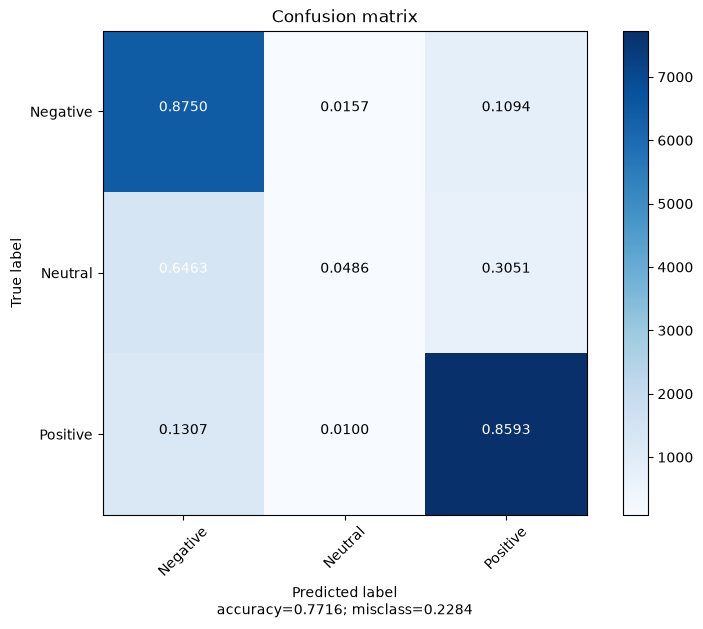

In [41]:
# Confusion matrix
plot_confusion_matrix.plot_confusion_matrix(
    confusion_matrix(y_test, y_test_pred_nb_bow),
    target_names=['Negative', 'Neutral', 'Positive']
)

##### Text Representation – N-gram

In [42]:
# Text representation using n-grams (unigrams and bigrams)
ngram_vectorizer  = CountVectorizer(ngram_range=(1, 2),
                                  tokenizer=identity_tokenizer,
                                  token_pattern=None,
                                  preprocessor=None,
                                  lowercase=False)

X_train_ngram = ngram_vectorizer.fit_transform(X_train)
X_test_ngram = ngram_vectorizer.transform(X_test)

# Train the Naive Bayes classifier
nb_ngram_model = MultinomialNB()
nb_ngram_model.fit(X_train_ngram, y_train)

# Generate predictions for the training and test sets
y_train_pred_nb_ngram = nb_ngram_model.predict(X_train_ngram)
y_test_pred_nb_ngram = nb_ngram_model.predict(X_test_ngram)

# Evaluate the model performance
nb_ngram_train_accuracy = accuracy_score(y_train, y_train_pred_nb_ngram)
nb_ngram_test_accuracy = accuracy_score(y_test, y_test_pred_nb_ngram)
print(f"Training set accuracy: {nb_ngram_train_accuracy}")
print(f"Test set accuracy: {nb_ngram_test_accuracy}")

# Display classification metrics for the test set
print(classification_report(y_test, y_test_pred_nb_ngram, target_names=['Negative', 'Neutral', 'Positive']))

Training set accuracy: 0.8884378986431636
Test set accuracy: 0.7797499864711294
              precision    recall  f1-score   support

    Negative       0.70      0.92      0.79      7342
     Neutral       0.67      0.00      0.01      2140
    Positive       0.87      0.85      0.86      8997

    accuracy                           0.78     18479
   macro avg       0.74      0.59      0.55     18479
weighted avg       0.78      0.78      0.73     18479



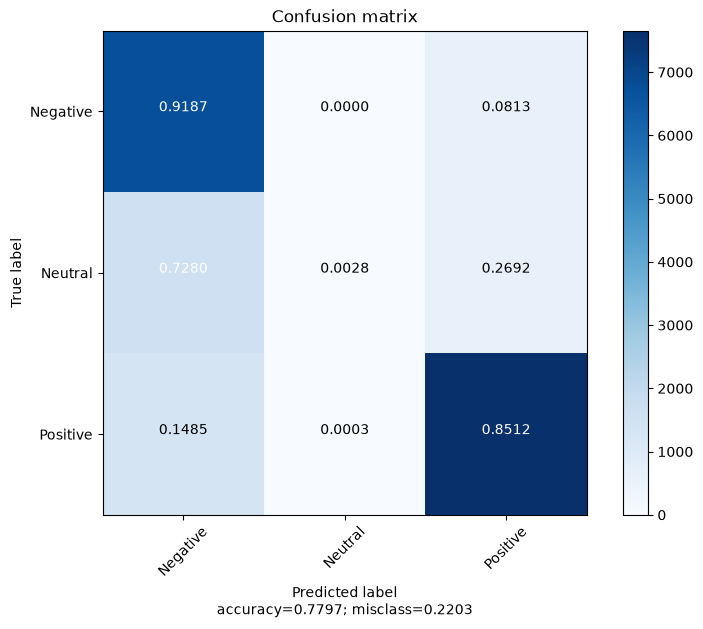

In [43]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test, y_test_pred_nb_ngram), target_names=['Negative','Neutral', 'Positive'])

##### Text Representation – TF-IDF

In [44]:
# Convert Bag-of-Words features into TF-IDF representation
tfidf_transformer = TfidfTransformer(
    use_idf=True,
    norm='l2',
    smooth_idf=True
)

X_train_tfidf = tfidf_transformer.fit_transform(X_train_bow)
X_test_tfidf = tfidf_transformer.transform(X_test_bow)

# Train the Naive Bayes classifier
nb_tfidf_model = MultinomialNB()
nb_tfidf_model.fit(X_train_tfidf, y_train)

# Generate predictions for the training and test sets
y_train_pred_nb_tfidf = nb_tfidf_model.predict(X_train_tfidf)
y_test_pred_nb_tfidf = nb_tfidf_model.predict(X_test_tfidf)

# Evaluate the model performance
nb_tfidf_train_accuracy = accuracy_score(y_train, y_train_pred_nb_tfidf)
nb_tfidf_test_accuracy = accuracy_score(y_test, y_test_pred_nb_tfidf)
print(f"Training set accuracy: {nb_tfidf_train_accuracy}")
print(f"Test set accuracy: {nb_tfidf_test_accuracy}")

# Display classification metrics for the test set
print(classification_report(y_test, y_test_pred_nb_tfidf, target_names=['Negative', 'Neutral', 'Positive']))

Training set accuracy: 0.7905137423170591
Test set accuracy: 0.7708209318686076
              precision    recall  f1-score   support

    Negative       0.70      0.89      0.78      7342
     Neutral       0.00      0.00      0.00      2140
    Positive       0.84      0.86      0.85      8997

    accuracy                           0.77     18479
   macro avg       0.51      0.58      0.54     18479
weighted avg       0.69      0.77      0.73     18479



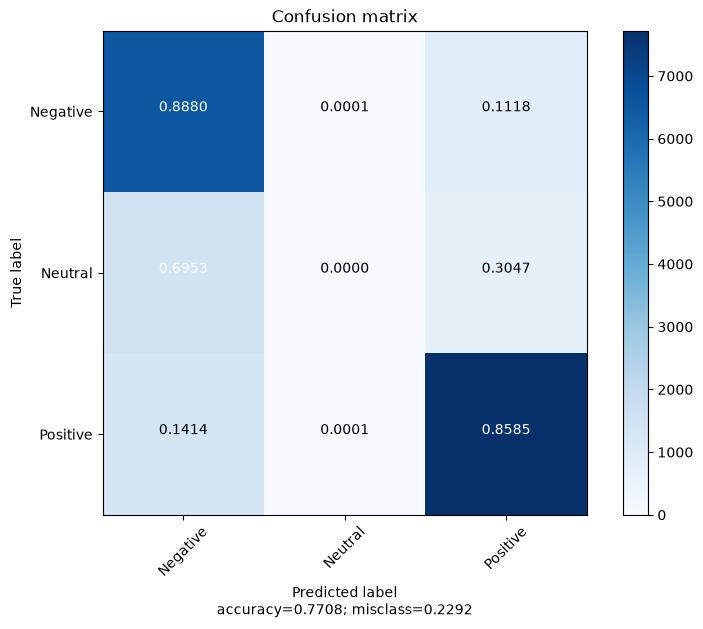

In [45]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test, y_test_pred_nb_tfidf), target_names=['Negative','Neutral', 'Positive'])

##### Comparison of Naive Bayes Models

In [46]:
# Create a comparison table for Naive Bayes models
nb_bow_report = classification_report(
    y_test,
    y_test_pred_nb_bow,
    output_dict=True
)

nb_ngram_report = classification_report(
    y_test,
    y_test_pred_nb_ngram,
    output_dict=True
)

nb_tfidf_report = classification_report(
    y_test,
    y_test_pred_nb_tfidf,
    output_dict=True
)

nb_results = pd.DataFrame({

    "Text Representation": ["BoW", "n-gram", "TF-IDF"],

    "Test Accuracy": [
        nb_bow_test_accuracy,
        nb_ngram_test_accuracy,
        nb_tfidf_test_accuracy
    ],

    "F1 Positive": [
        nb_bow_report["Positive"]["f1-score"],
        nb_ngram_report["Positive"]["f1-score"],
        nb_tfidf_report["Positive"]["f1-score"]
    ],

    "F1 Neutral": [
        nb_bow_report["Neutral"]["f1-score"],
        nb_ngram_report["Neutral"]["f1-score"],
        nb_tfidf_report["Neutral"]["f1-score"]
    ],

    "F1 Negative": [
        nb_bow_report["Negative"]["f1-score"],
        nb_ngram_report["Negative"]["f1-score"],
        nb_tfidf_report["Negative"]["f1-score"]
    ]
})

nb_results.round(2)

,Text Representation,Test Accuracy,F1 Positive,F1 Neutral,F1 Negative
0,BoW,0.77,0.85,0.08,0.79
1,n-gram,0.78,0.86,0.01,0.79
2,TF-IDF,0.77,0.85,0.00,0.78


All Naive Bayes models achieved similar accuracy, at approximately 0.77, regardless of the text representation used. Performance on the positive and negative classes was also comparable across models, with F1-scores of around 0.85 and 0.79, respectively. The main difference was observed for the neutral class, which proved difficult to classify in all cases. However, the BoW representation achieved a noticeably higher F1-score for the neutral class (0.08) than the other representations, where the F1-score was closer to 0.

#### Modelling – Logistic Regression

##### Text Representation – Bag of Words (BoW)

In [47]:
# Encoding class labels (positive=0, neutral=1, negative=2)
y_train_encoded = y_train.map({'Positive': 0, 'Neutral': 1, 'Negative': 2})
y_test_encoded = y_test.map({'Positive': 0, 'Neutral': 1, 'Negative': 2})

# Train the Logistic Regression classifier
lr_bow_model = LogisticRegression(max_iter=1000)
lr_bow_model.fit(X_train_bow, y_train_encoded)

# Generate predictions for the training and test sets
y_train_pred_lr_bow = lr_bow_model.predict(X_train_bow)
y_test_pred_lr_bow = lr_bow_model.predict(X_test_bow)

# Evaluate the model performance
lr_bow_train_accuracy = accuracy_score(y_train_encoded, y_train_pred_lr_bow)
lr_bow_test_accuracy = accuracy_score(y_test_encoded, y_test_pred_lr_bow)
print(f"Training set accuracy: {lr_bow_train_accuracy}")
print(f"Test set accuracy: {lr_bow_test_accuracy}")

# Display classification metrics for the test set
print(classification_report(y_test_encoded, y_test_pred_lr_bow, target_names=['Positive', 'Neutral', 'Negative']))

Training set accuracy: 0.8570567088020411
Test set accuracy: 0.7685480816061475
              precision    recall  f1-score   support

    Positive       0.82      0.88      0.85      8997
     Neutral       0.33      0.12      0.17      2140
    Negative       0.75      0.82      0.78      7342

    accuracy                           0.77     18479
   macro avg       0.63      0.61      0.60     18479
weighted avg       0.73      0.77      0.74     18479



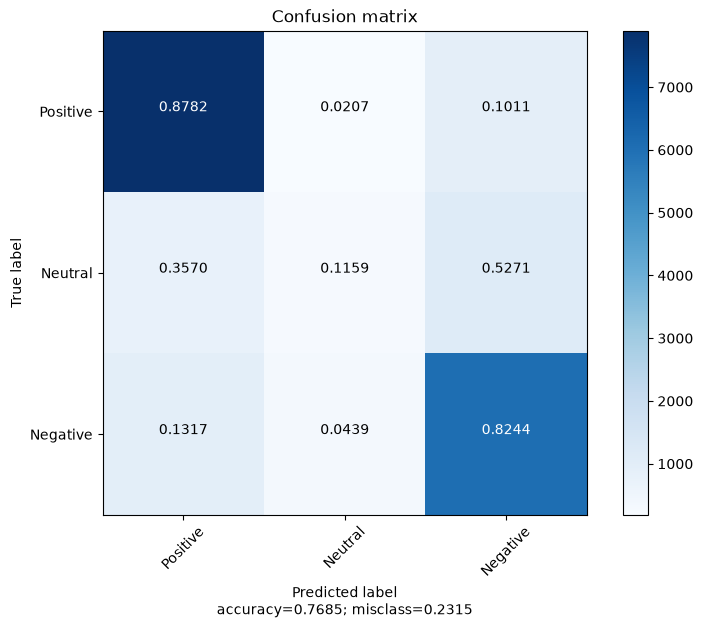

In [48]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test_encoded, y_test_pred_lr_bow), target_names=['Positive', 'Neutral', 'Negative'])

##### Text Representation – N-gram

In [49]:
# Train the Logistic Regression classifier
lr_ngram_model = LogisticRegression(max_iter=1000)
lr_ngram_model.fit(X_train_ngram, y_train_encoded)

# Generate predictions for the training and test sets
y_train_pred_lr_ngram = lr_ngram_model.predict(X_train_ngram)
y_test_pred_lr_ngram = lr_ngram_model.predict(X_test_ngram)

# Evaluate the model performance
lr_ngram_train_accuracy = accuracy_score(y_train_encoded, y_train_pred_lr_ngram)
lr_ngram_test_accuracy = accuracy_score(y_test_encoded, y_test_pred_lr_ngram)
print(f"Training set accuracy: {lr_ngram_train_accuracy}")
print(f"Test set accuracy: {lr_ngram_test_accuracy}")

# Display classification metrics for the test set
print(classification_report(y_test_encoded, y_test_pred_lr_ngram, target_names=['Positive', 'Neutral', 'Negative']))

Training set accuracy: 0.9901426417720051
Test set accuracy: 0.7783429839277017
              precision    recall  f1-score   support

    Positive       0.84      0.88      0.86      8997
     Neutral       0.34      0.12      0.18      2140
    Negative       0.75      0.84      0.79      7342

    accuracy                           0.78     18479
   macro avg       0.64      0.62      0.61     18479
weighted avg       0.75      0.78      0.75     18479



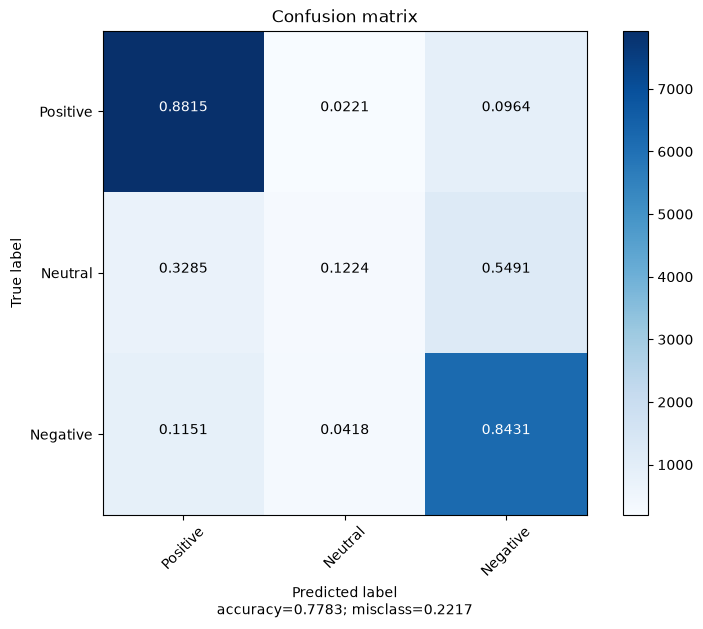

In [50]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test_encoded, y_test_pred_lr_ngram), target_names=['Positive', 'Neutral', 'Negative'])

##### Text Representation – TF-IDF

In [51]:
# Train the Logistic Regression model
lr_tfidf_model = LogisticRegression(max_iter=1000)
lr_tfidf_model.fit(X_train_tfidf, y_train_encoded)

# Generate predictions for the training and test sets
y_train_pred_lr_tfidf = lr_tfidf_model.predict(X_train_tfidf)
y_test_pred_lr_tfidf = lr_tfidf_model.predict(X_test_tfidf)

# Evaluate the model performance
lr_tfidf_train_accuracy = accuracy_score(y_train_encoded, y_train_pred_lr_tfidf)
lr_tfidf_test_accuracy = accuracy_score(y_test_encoded, y_test_pred_lr_tfidf)
print(f"Training set accuracy: {lr_tfidf_train_accuracy}")
print(f"Test set accuracy: {lr_tfidf_test_accuracy}")

# Display classification metrics for the test set
print(classification_report(y_test_encoded, y_test_pred_lr_tfidf, target_names=['Positive', 'Neutral', 'Negative']))

Training set accuracy: 0.8176736634581933
Test set accuracy: 0.7821310676984685
              precision    recall  f1-score   support

    Positive       0.84      0.88      0.86      8997
     Neutral       0.40      0.05      0.09      2140
    Negative       0.73      0.88      0.80      7342

    accuracy                           0.78     18479
   macro avg       0.66      0.60      0.58     18479
weighted avg       0.75      0.78      0.75     18479



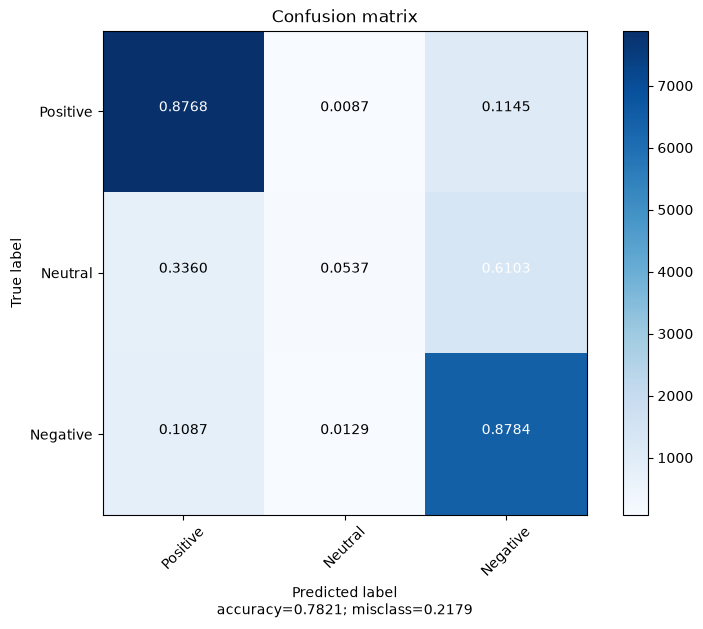

In [52]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test_encoded, y_test_pred_lr_tfidf), target_names=['Positive', 'Neutral', 'Negative'])

##### Comparison of Logistic Regression Models

In [53]:
# Create a comparison table for Logistic Regression models

lr_bow_report = classification_report(
    y_test_encoded,
    y_test_pred_lr_bow,
    target_names=['Positive', 'Neutral', 'Negative'],
    output_dict=True
)

lr_ngram_report = classification_report(
    y_test_encoded,
    y_test_pred_lr_ngram,
    target_names=['Positive', 'Neutral', 'Negative'],
    output_dict=True
)

lr_tfidf_report = classification_report(
    y_test_encoded,
    y_test_pred_lr_tfidf,
    target_names=['Positive', 'Neutral', 'Negative'],
    output_dict=True
)

lr_results = pd.DataFrame({

    "Text Representation": ["BoW", "n-gram", "TF-IDF"],

    "Test Accuracy": [
        lr_bow_test_accuracy,
        lr_ngram_test_accuracy,
        lr_tfidf_test_accuracy
    ],

    "F1 Positive": [
        lr_bow_report["Positive"]["f1-score"],
        lr_ngram_report["Positive"]["f1-score"],
        lr_tfidf_report["Positive"]["f1-score"]

    ],

    "F1 Neutral": [
        lr_bow_report["Neutral"]["f1-score"],
        lr_ngram_report["Neutral"]["f1-score"],
        lr_tfidf_report["Neutral"]["f1-score"]
    ],

    "F1 Negative": [
        lr_bow_report["Negative"]["f1-score"],
        lr_ngram_report["Negative"]["f1-score"],
        lr_tfidf_report["Negative"]["f1-score"]
    ]
})

lr_results.round(2)

,Text Representation,Test Accuracy,F1 Positive,F1 Neutral,F1 Negative
0,BoW,0.77,0.85,0.17,0.78
1,n-gram,0.78,0.86,0.18,0.79
2,TF-IDF,0.78,0.86,0.09,0.80


The Logistic Regression models produced broadly similar results across the three text representations, with test accuracy of approximately 0.78. F1-scores for the positive and negative classes were also comparable across models (around 0.86 and 0.79, respectively). The largest difference was observed for the neutral class: the BoW and n-gram representations achieved F1-scores of approximately 0.17–0.18, whereas the TF-IDF representation achieved an F1-score of only 0.09.

### Tuning the Best Models

#### Naive Bayes with BoW Text Representation + Best Alpha

The α (alpha) parameter controls the amount of smoothing applied by the Naive Bayes classifier. Lower values place greater emphasis on the observed word frequencies, whereas higher values apply stronger smoothing. Since the neutral class proved difficult to classify, lower α values were evaluated to investigate whether weaker smoothing could improve the balance between the sentiment classes. Since the goal of the project is to correctly classify reviews into all three sentiment classes, the macro-averaged F1-score was used to evaluate the tested α values during hyperparameter tuning. Unlike accuracy, this metric gives equal importance to positive, neutral, and negative reviews, making it more appropriate for the imbalanced dataset. The default value (α = 1.0) was retained as a baseline for comparison.

In [54]:
# Define the range of alpha values to evaluate
alpha_grid = [{'alpha' : [0.1, 0.3, 0.5, 0.7, 1]}]

# Define the cross-validation strategy
cv_strategy = ShuffleSplit(
    n_splits=3, 
    test_size=0.3, 
    random_state=RANDOM_STATE
    )

# Perform grid search using macro-averaged F1-score
nb_grid_search = GridSearchCV(
    MultinomialNB(),
    alpha_grid,
    cv=cv_strategy,
    scoring='f1_macro'
    )

# Fit the models and evaluate each alpha value
nb_grid_search.fit(X_train_bow, y_train)

# Store the results in a DataFrame
nb_alpha_tuning_results = pd.DataFrame({
    "alpha": [p["alpha"] for p in nb_grid_search.cv_results_["params"]],
    "mean_cv_score": nb_grid_search.cv_results_["mean_test_score"]
})

# Display the mean cross-validation F1-score for each alpha value
print("Cross-validation macro F1-score by alpha:")
for alpha, score in zip(nb_alpha_tuning_results["alpha"], nb_alpha_tuning_results["mean_cv_score"]):
    print(f"α = {alpha}: {score:.3f}")

Cross-validation macro F1-score by alpha:
α = 0.1: 0.615
α = 0.3: 0.605
α = 0.5: 0.594
α = 0.7: 0.582
α = 1.0: 0.570


The highest macro-averaged F1-score (0.615) was achieved for α = 0.1. Performance decreased gradually as α increased, suggesting that weaker smoothing leads to a better balance between the three sentiment classes. Therefore, α = 0.1 was selected for further evaluation.

In [55]:
# Train the Naive Bayes model with alpha = 0.1
nb_bow_alpha01_model = MultinomialNB(alpha = 0.1)
nb_bow_alpha01_model.fit(X_train_bow, y_train)

# Generate predictions for the training and test sets
y_train_pred_nb_bow_alpha01 = nb_bow_alpha01_model.predict(X_train_bow)
y_test_pred_nb_bow_alpha01 = nb_bow_alpha01_model.predict(X_test_bow)

# Evaluate the model performance
nb_bow_alpha01_train_accuracy = accuracy_score(y_train, y_train_pred_nb_bow_alpha01)
nb_bow_alpha01_test_accuracy = accuracy_score(y_test, y_test_pred_nb_bow_alpha01)
print(f"Training set accuracy: {nb_bow_alpha01_train_accuracy}")
print(f"Test set accuracy: {nb_bow_alpha01_test_accuracy}")

# Display classification metrics for the test set
print(classification_report(y_test, y_test_pred_nb_bow_alpha01, target_names=['Negative', 'Neutral', 'Positive']))

Training set accuracy: 0.8260698132900383
Test set accuracy: 0.7561015206450565
              precision    recall  f1-score   support

    Negative       0.74      0.82      0.77      7342
     Neutral       0.28      0.18      0.22      2140
    Positive       0.84      0.85      0.84      8997

    accuracy                           0.76     18479
   macro avg       0.62      0.61      0.61     18479
weighted avg       0.74      0.76      0.74     18479



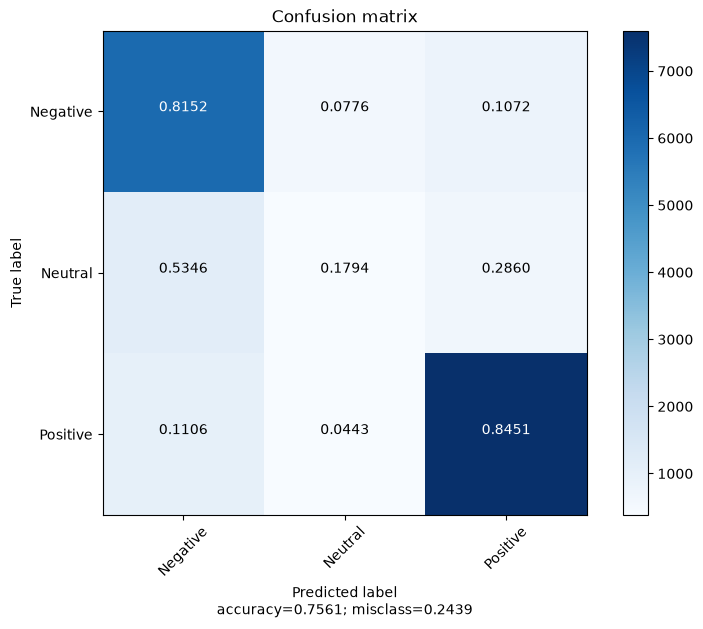

In [56]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test, y_test_pred_nb_bow_alpha01), target_names=['Negative','Neutral', 'Positive'])

In [57]:
report_alpha01 = classification_report(
    y_test,
    y_test_pred_nb_bow_alpha01,
    output_dict=True
)

nb_alpha = pd.DataFrame({

    "Class": ["Positive", "Neutral", "Negative"],

    "F1 (alpha=1.0)": [
        nb_bow_report["Positive"]["f1-score"],
        nb_bow_report["Neutral"]["f1-score"],
        nb_bow_report["Negative"]["f1-score"]
    ],

    "F1 (alpha=0.1)": [
        report_alpha01["Positive"]["f1-score"],
        report_alpha01["Neutral"]["f1-score"],
        report_alpha01["Negative"]["f1-score"]
    ]
})

nb_alpha.round(2)

,Class,F1 (alpha=1.0),F1 (alpha=0.1)
0,Positive,0.85,0.84
1,Neutral,0.08,0.22
2,Negative,0.79,0.77


Compared with the original model (α = 1.0), the model using α = 0.1 achieved a much higher F1-score for the neutral class (0.22 vs 0.08). At the same time, the F1-scores for the positive and negative classes decreased a little. Overall, reducing the amount of smoothing improved the model’s ability to identify neutral reviews while maintaining similar performance for the positive and negative classes.

#### Logistic Regression with N-gram Text Representation + Class Weight Balancing + Best C

The n-gram representation was selected for further Logistic Regression tuning because it achieved performance comparable to the other text representations while producing the highest F1-score for the neutral class. Since the dataset is imbalanced and neutral reviews remain the most difficult to classify, class weight balancing will be applied to reduce the influence of the majority classes. In addition, the C parameter will be tuned. The C parameter controls the strength of regularisation in Logistic Regression: lower values of C apply stronger regularisation, reducing the influence of individual features on the model. Lower C values will therefore be evaluated to investigate whether stronger regularisation encourages the model to learn more general patterns and improves the identification of neutral reviews, while maintaining satisfactory performance on the positive and negative classes. The tested C values will be evaluated using the macro-averaged F1-score.

In [58]:
# Define the range of C values to evaluate
c_grid = {'C': [0.1, 0.3, 0.5, 0.7, 1]}

# Perform grid search using macro-averaged F1-score
lr_grid_search = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=1000),
                   c_grid,
                   cv=cv_strategy,    # Use the same cross-validation strategy as in the Naive Bayes tuning
                   scoring='f1_macro')

# Fit the models and evaluate each C value
lr_grid_search.fit(X_train_ngram, y_train_encoded)

# Store the results in a DataFrame
lr_c_tuning_results = pd.DataFrame({
    "C": [p["C"] for p in lr_grid_search.cv_results_["params"]],
    "mean_cv_score": lr_grid_search.cv_results_["mean_test_score"]
})

# Display the mean cross-validation F1-score for each C value
print("Cross-validation macro F1-score by C:")
for c_value, score in zip(lr_c_tuning_results["C"], lr_c_tuning_results["mean_cv_score"]):
    print(f"C = {c_value}: {score:.3f}")

Cross-validation macro F1-score by C:
C = 0.1: 0.641
C = 0.3: 0.635
C = 0.5: 0.632
C = 0.7: 0.629
C = 1.0: 0.627


The highest macro-averaged F1-score (0.641) was achieved for C = 0.1. Performance decreased gradually as C increased, suggesting that stronger regularisation leads to a better balance between the three sentiment classes. Therefore, C = 0.1 was selected for further evaluation.

In [59]:
# Train the Logistic Regression classifier with C = 0.1
lr_ngram_balanced_c01_model = LogisticRegression(class_weight='balanced', C = 0.1, max_iter=1000)
lr_ngram_balanced_c01_model.fit(X_train_ngram, y_train_encoded)

# Generate predictions for the training and test sets
y_train_pred_lr_ngram_balanced_c01 = lr_ngram_balanced_c01_model.predict(X_train_ngram)
y_test_pred_lr_ngram_balanced_c01 = lr_ngram_balanced_c01_model.predict(X_test_ngram)

# Evaluate the model performance
lr_ngram_balanced_c01_train_accuracy = accuracy_score(y_train_encoded, y_train_pred_lr_ngram_balanced_c01)
lr_ngram_balanced_c01_test_accuracy = accuracy_score(y_test_encoded, y_test_pred_lr_ngram_balanced_c01)
print(f"Training set accuracy: {lr_ngram_balanced_c01_train_accuracy}")
print(f"Test set accuracy: {lr_ngram_balanced_c01_test_accuracy}")

# Display classification metrics for the test set
print(classification_report(y_test_encoded, y_test_pred_lr_ngram_balanced_c01, target_names=['Positive', 'Neutral', 'Negative']))

Training set accuracy: 0.9269859677606401
Test set accuracy: 0.7592943341089886
              precision    recall  f1-score   support

    Positive       0.86      0.85      0.86      8997
     Neutral       0.28      0.29      0.28      2140
    Negative       0.77      0.79      0.78      7342

    accuracy                           0.76     18479
   macro avg       0.64      0.64      0.64     18479
weighted avg       0.76      0.76      0.76     18479



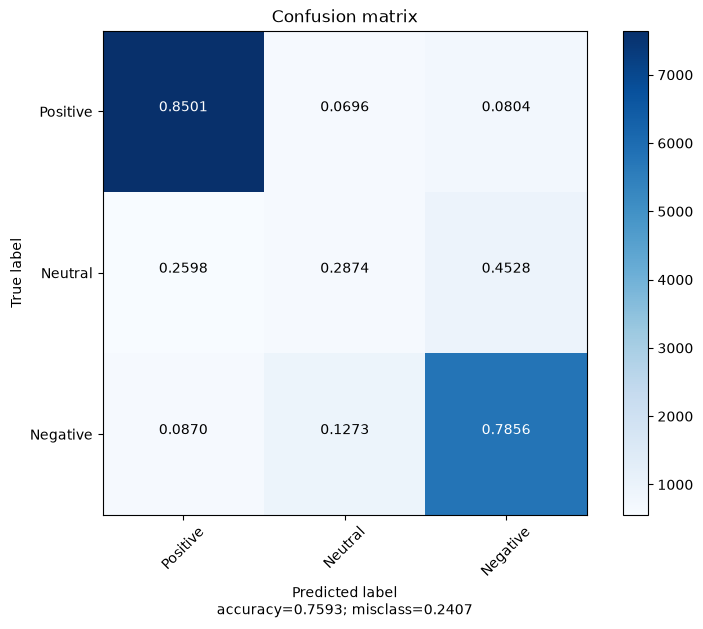

In [60]:
plot_confusion_matrix.plot_confusion_matrix(confusion_matrix(y_test_encoded, y_test_pred_lr_ngram_balanced_c01), target_names=['Positive','Neutral','Negative'])

In [61]:
lr_ngram_balanced_c01_report= classification_report(
    y_test_encoded, 
    y_test_pred_lr_ngram_balanced_c01,
    target_names=['Positive', 'Neutral', 'Negative'],
    output_dict=True
)

lr_c_results = pd.DataFrame({

    "Class": ["Positive", "Neutral", "Negative"],

    "F1 (C=1.0)": [
        lr_ngram_report["Positive"]["f1-score"],
        lr_ngram_report["Neutral"]["f1-score"],
        lr_ngram_report["Negative"]["f1-score"]
    ],

    "F1 (C=0.1)": [
        lr_ngram_balanced_c01_report["Positive"]["f1-score"],
        lr_ngram_balanced_c01_report["Neutral"]["f1-score"],
        lr_ngram_balanced_c01_report["Negative"]["f1-score"]
    ]
})

lr_c_results.round(2)

,Class,F1 (C=1.0),F1 (C=0.1)
0,Positive,0.86,0.86
1,Neutral,0.18,0.28
2,Negative,0.79,0.78


After tuning Logistic Regression with class weight balancing and C = 0.1, the F1-score for the neutral class increased from 0.18 to 0.28. The F1-score for the positive class remained unchanged at 0.86, while the negative class decreased only slightly from 0.79 to 0.78. Overall, the tuned model improved the identification of neutral reviews while keeping similar performance for the positive and negative classes.

## Conclusions

TextBlob produced similar results across all text representations, indicating that preprocessing had little effect on the performance of this lexicon-based approach. It classified positive reviews reasonably well but performed poorly on negative and especially neutral reviews.

Machine learning models substantially outperformed TextBlob, demonstrating the advantage of training classifiers on domain-specific review data.

Both Naive Bayes and Logistic Regression classified positive and negative reviews effectively, whereas neutral reviews remained the most challenging sentiment category throughout the analysis.

The choice of text representation affected model performance. TF-IDF generally produced the weakest results for neutral sentiment classification. For Naive Bayes, the Bag of Words representation achieved the most balanced performance across the three sentiment classes, whereas n-grams performed best for Logistic Regression.

Hyperparameter tuning improved the ability of both classifiers to identify neutral reviews. For Naive Bayes, reducing the smoothing parameter α increased the F1-score for the neutral class from 0.08 to 0.22. For Logistic Regression, class weight balancing combined with stronger regularisation increased the neutral-class F1-score from 0.18 to 0.28.

The best-performing model was the tuned Logistic Regression classifier with n-gram text representation, class weight balancing, and C = 0.1. It achieved the best overall balance in classifying the three sentiment classes, although neutral reviews remained difficult to identify accurately. The model may therefore be more suitable for applications focused on distinguishing between positive and negative feedback than for precise three-class sentiment classification.

## Suggested Further Improvements

* Analyse neutral reviews in more detail to better understand why they are difficult to classify and how they differ from positive and negative reviews.
* Test other methods for dealing with class imbalance, especially in the Naive Bayes model, where automatic class weighting is not available.
* Tune additional model parameters to investigate whether further improvements in classification performance can be achieved.
* Review the sentiment labelling strategy by changing how ratings are assigned to sentiment classes. Increasing the number of neutral reviews may help the models learn this class more effectively.
* Test additional classification algorithms, such as Support Vector Machines (SVM) or more advanced language models, to determine whether they can improve the classification of neutral reviews.